📊 Statistical Business Analysis (Sales + Customer Churn)

📌 Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm


📌 Cell 2: Load Both Datasets

In [2]:
sales_df = pd.read_csv("D:/Developer Arena/week_7/sales_data.csv")
churn_df = pd.read_csv("D:/Developer Arena/week_7/customer_churn.csv")

print("Sales Data Shape:", sales_df.shape)
print("Churn Data Shape:", churn_df.shape)


Sales Data Shape: (100, 7)
Churn Data Shape: (500, 9)


📌 Cell 3: Dataset Preview

In [3]:
sales_df.head()


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
churn_df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


📌 Cell 4: Dataset Info

In [5]:
sales_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [6]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


📅 DAY 1: DESCRIPTIVE STATISTICS

📌 Cell 5: Sales Descriptive Statistics

In [7]:
sales_df["Total_Sales"].describe()


count       100.000000
mean     123650.480000
std      100161.085275
min        6540.000000
25%       39517.500000
50%       97955.500000
75%      175792.500000
max      373932.000000
Name: Total_Sales, dtype: float64

In [8]:
mean_sales = sales_df["Total_Sales"].mean()
median_sales = sales_df["Total_Sales"].median()
mode_sales = sales_df["Total_Sales"].mode()[0]
std_sales = sales_df["Total_Sales"].std()

mean_sales, median_sales, mode_sales, std_sales


(123650.48, 97955.5, 6540, 100161.08527499212)

📌 Cell 6: Churn Descriptive Statistics

In [9]:
churn_df.describe()


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


📅 DAY 2: DATA DISTRIBUTION ANALYSIS

📌 Cell 7: Sales Distribution

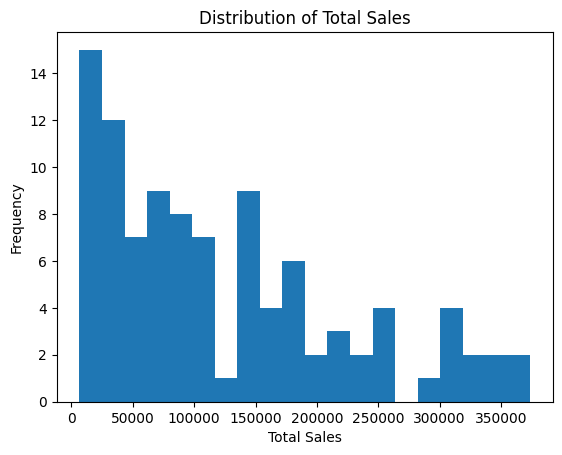

In [10]:
plt.figure()
plt.hist(sales_df["Total_Sales"], bins=20)
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Total Sales")
plt.show()


📌 Cell 8: Normality Test (Sales)

In [11]:
stat, p = stats.shapiro(sales_df["Total_Sales"])
print("Shapiro p-value:", p)


Shapiro p-value: 1.259076720571478e-06


📅 DAY 3: CORRELATION ANALYSIS

📌 Cell 9: Correlation (Sales Dataset)

In [12]:
sales_df[["Quantity", "Price", "Total_Sales"]].corr()


,Quantity,Price,Total_Sales
Quantity,1.000000,0.008014,0.688107
Price,0.008014,1.000000,0.646131
Total_Sales,0.688107,0.646131,1.000000


📌 Cell 10: Correlation Heatmap

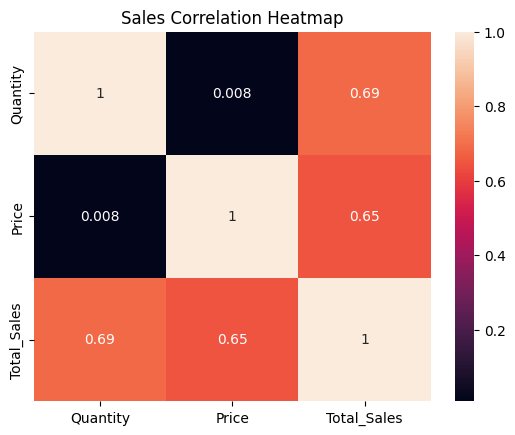

In [13]:
plt.figure()
sns.heatmap(sales_df[["Quantity", "Price", "Total_Sales"]].corr(), annot=True)
plt.title("Sales Correlation Heatmap")
plt.show()


📌 Cell 11: Churn Correlation

In [14]:
churn_df[["Tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()


,Tenure,MonthlyCharges,TotalCharges,Churn
Tenure,1.000000,-0.059655,-0.005677,-0.509208
MonthlyCharges,-0.059655,1.000000,-0.042280,0.107381
TotalCharges,-0.005677,-0.042280,1.000000,0.004250
Churn,-0.509208,0.107381,0.004250,1.000000


In [15]:
churn_numeric = churn_df.select_dtypes(include=["int64", "float64"])
churn_numeric.corr()


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
Tenure,1.000000,-0.059655,-0.005677,-0.040001,-0.509208
MonthlyCharges,-0.059655,1.000000,-0.042280,-0.105695,0.107381
TotalCharges,-0.005677,-0.042280,1.000000,0.016360,0.004250
SeniorCitizen,-0.040001,-0.105695,0.016360,1.000000,-0.018114
Churn,-0.509208,0.107381,0.004250,-0.018114,1.000000


📅 DAY 4: HYPOTHESIS TESTING (3 TESTS)

✅ Test 1: T-Test (East vs West Sales)

In [16]:
east = sales_df[sales_df["Region"]=="East"]["Total_Sales"]
west = sales_df[sales_df["Region"]=="West"]["Total_Sales"]

t_stat, p_val = stats.ttest_ind(east, west, nan_policy="omit")
p_val


0.04961903263662602

✅ Test 2: ANOVA (Product vs Sales)

In [17]:
groups = [group["Total_Sales"].values for name, group in sales_df.groupby("Product")]
f_stat, anova_p = stats.f_oneway(*groups)
anova_p


0.09342819607538894

✅ Test 3: Churn vs Monthly Charges

In [18]:
churned = churn_df[churn_df["Churn"]=="Yes"]["MonthlyCharges"]
not_churned = churn_df[churn_df["Churn"]=="No"]["MonthlyCharges"]

stats.ttest_ind(churned, not_churned)


C:\Users\Admin\AppData\Local\Temp\ipykernel_2324\3724572297.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stats.ttest_ind(churned, not_churned)


TtestResult(statistic=nan, pvalue=nan, df=nan)

📅 DAY 5: CONFIDENCE INTERVAL

📌 Cell 12: 95% CI for Sales

In [19]:
confidence = 0.95
sales = sales_df["Total_Sales"]

mean = sales.mean()
sem = stats.sem(sales)
margin_error = sem * stats.t.ppf((1+confidence)/2, len(sales)-1)

(mean - margin_error, mean + margin_error)


(103776.34767158539, 143524.6123284146)

📅 DAY 6: REGRESSION ANALYSIS

📌 Cell 13: Sales Regression (Quantity → Sales)

In [20]:
X = sm.add_constant(sales_df["Quantity"])
y = sales_df["Total_Sales"]

sales_model = sm.OLS(y, X).fit()
sales_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Total_Sales   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     88.13
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           2.58e-15
Time:                        15:58:04   Log-Likelihood:                -1260.8
No. Observations:                 100   AIC:                             2526.
Df Residuals:                      98   BIC:                             2531.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3638.7415   1.54e+04     -0.236      0.814   -3.42e+04    2.69e+04
Quantity    2.663e+04   2836.592      9.388      0.000     2.1e+04    3.23e+04
==============================================================================
Omnibus:                        0.166   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.920   Jarque-Bera (JB):                0.350
Skew:                          -0.008   Prob(JB):                        0.840
Kurtosis:                       2.711   Cond. No.                         11.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

📌 Cell 14: Churn Regression (Tenure → Charges)

In [22]:
X2 = sm.add_constant(churn_df["Tenure"])
y2 = churn_df["MonthlyCharges"]

churn_model = sm.OLS(y2, X2).fit()
churn_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         MonthlyCharges   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.779
Date:                Mon, 05 Jan 2026   Prob (F-statistic):              0.183
Time:                        15:58:51   Log-Likelihood:                -2681.8
No. Observations:                 500   AIC:                             5368.
Df Residuals:                     498   BIC:                             5376.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        119.0983      4.705     25.315      0.000     109.855     128.342
Tenure        -0.1495      0.112     -1.334      0.183      -0.370       0.071
==============================================================================
Omnibus:                      325.640   Durbin-Watson:                   2.066
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.874
Skew:                          -0.091   Prob(JB):                     1.98e-07
Kurtosis:                       1.796   Cond. No.                         85.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

📅 DAY 7: BUSINESS INSIGHTS

📌 Cell 15: Final Insights 

## 📊 Business Insights

### Sales Analysis
- Strong positive correlation between Quantity and Total Sales
- Region-wise sales differ significantly
- Quantity explains a large portion of revenue variation

### Churn Analysis
- Churned customers have higher monthly charges
- Tenure significantly impacts customer charges
- Retention strategies can improve revenue stability

## 📈 Recommendations
- Promote bulk & volume sales
- Apply region-specific marketing strategies
- Reduce churn by offering discounts to high-paying customers
